# Championship Final Day Predictions 2025/26 - Promotion Race Analysis  

**Competition:** EFL Championship 2025/26  
**Purpose:** Model promotion and play-off probabilities heading into the final matchday using simulation-based analysis.  
**Data:** League table positions, remaining fixtures, and Monte Carlo simulation outputs (10,000 runs).  
**Methods:** Scenario simulation, probability tracking over time, rolling outcome distributions, and final-day projection analysis.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  

**Articles:** [Championship Final Day Predictions 2025/26: Who Gets Promoted to the Premier League?](https://medium.com/@vickyfrissdekereki/championship-final-day-predictions-2025-26-who-gets-promoted-to-the-premier-league-8b058f613663)  

**Live Simulator:**  [Football League Simulator](https://football-league-simulator.streamlit.app/  )   

**Notebook first written:** `01/05/2026`  
**Last updated:** `01/05/2026`  

> This notebook analyses promotion probability dynamics in the Championship using Monte Carlo simulation.  
>
> The focus is on how uncertainty evolves heading into the final matchday, with particular emphasis on the automatic promotion (top 2) and final play-off (6th) thresholds.  
>
> Results are presented as evolving probability distributions rather than deterministic predictions, highlighting the volatility of end-of-season outcomes.

<div style="text-align: left;">
    <img src="Images and others/cover_image_championship_promotion_race.jpg" alt="cover_image_championship_promotion_race" width="600">
</di>
>

In [1]:
import pandas as pd
from pathlib import Path
import re

BASE_PATH = Path(r"C:\Users\vicky\Desktop\football-league-predictions\data\simulations")

snapshots = []
ts_pattern = re.compile(r"^\d{8}_\d{6}$")

# ---------------------------------------------------
# 1. Load snapshots properly
# ---------------------------------------------------
for folder in sorted(BASE_PATH.iterdir()):
    if not folder.is_dir():
        continue

    if "SCENARIO" in folder.name.upper():
        continue

    if not ts_pattern.match(folder.name):
        continue

    file_path = folder / "championship_england_simulation.csv"

    if not file_path.exists():
        continue

    df = pd.read_csv(file_path)

    # parse folder timestamp
    df["date"] = pd.to_datetime(folder.name, format="%Y%m%d_%H%M%S")

    snapshots.append(df)

print(f"Snapshots loaded: {len(snapshots)}")

# ---------------------------------------------------
# 2. Build clean dataset WITH correct structure
# ---------------------------------------------------
all_data = []

for snap in snapshots:
    snap = snap.copy()

    teams = [c for c in snap.columns if c != "date"]

    # normalise probabilities
    snap[teams] = snap[teams] / 10000

    snap["position"] = range(1, len(snap) + 1)

    all_data.append(snap)

df = pd.concat(all_data, ignore_index=True)

# ---------------------------------------------------
# 3. Define race teams
# ---------------------------------------------------
second_teams = ["Ipswich Town", "Millwall", "Middlesbrough"]
sixth_teams = ["Wrexham", "Hull City", "Derby County"]

# ---------------------------------------------------
# 4. Extract correct slices
# ---------------------------------------------------
second_place = df[df["position"] == 2].set_index("date")[second_teams].T
sixth_place = df[df["position"] == 6].set_index("date")[sixth_teams].T

# ---------------------------------------------------
# 5. KEEP ONLY FIRST SNAPSHOT PER DAY
# ---------------------------------------------------
def drop_duplicate_dates(df):
    cols = pd.to_datetime(df.columns)
    day = cols.date  # strip time

    mask = ~pd.Series(day).duplicated(keep="first")
    df = df.loc[:, mask.values]

    return df

second_place = drop_duplicate_dates(second_place)
sixth_place = drop_duplicate_dates(sixth_place)

# sort chronologically
second_place = second_place.sort_index(axis=1)
sixth_place = sixth_place.sort_index(axis=1)

# ---------------------------------------------------
# 6. CHECK OUTPUT
# ---------------------------------------------------
print("SECOND PLACE SAMPLE:")
display(second_place.head())

print("SIXTH PLACE SAMPLE:")
display(sixth_place.head())

Snapshots loaded: 41
SECOND PLACE SAMPLE:


date,2026-03-28 21:06:13,2026-04-01 00:58:26,2026-04-02 18:47:05,2026-04-03 13:06:33,2026-04-04 13:04:26,2026-04-05 07:30:36,2026-04-06 08:08:20,2026-04-07 07:54:52,2026-04-08 07:58:58,2026-04-11 07:23:08,...,2026-04-19 07:48:42,2026-04-20 01:29:48,2026-04-21 21:16:35,2026-04-22 08:12:13,2026-04-24 12:57:18,2026-04-25 07:50:27,2026-04-26 14:59:45,2026-04-27 00:03:10,2026-04-28 14:41:44,2026-05-01 15:25:25
Ipswich Town,0.4487,0.4564,0.4801,0.5043,0.5496,0.5516,0.5585,0.7483,0.7453,0.7263,...,0.6715,0.6291,0.5857,0.6043,0.7418,0.8166,0.8055,0.8076,0.8050,0.8041
Millwall,0.0883,0.0765,0.0821,0.0788,0.2051,0.2055,0.1989,0.0713,0.0649,0.0568,...,0.1218,0.1497,0.3506,0.3436,0.2384,0.1580,0.1527,0.1579,0.1604,0.1824
Middlesbrough,0.4461,0.4499,0.4197,0.3978,0.2357,0.2328,0.2339,0.1691,0.1687,0.2013,...,0.0610,0.0271,0.0180,0.0121,0.0060,0.0087,0.0235,0.0200,0.0204,0.0135


SIXTH PLACE SAMPLE:


date,2026-03-28 21:06:13,2026-04-01 00:58:26,2026-04-02 18:47:05,2026-04-03 13:06:33,2026-04-04 13:04:26,2026-04-05 07:30:36,2026-04-06 08:08:20,2026-04-07 07:54:52,2026-04-08 07:58:58,2026-04-11 07:23:08,...,2026-04-19 07:48:42,2026-04-20 01:29:48,2026-04-21 21:16:35,2026-04-22 08:12:13,2026-04-24 12:57:18,2026-04-25 07:50:27,2026-04-26 14:59:45,2026-04-27 00:03:10,2026-04-28 14:41:44,2026-05-01 15:25:25
Wrexham,0.2212,0.2183,0.2120,0.2041,0.2254,0.2292,0.2261,0.2025,0.0816,0.1002,...,0.2206,0.2258,0.4963,0.4833,0.5054,0.4942,0.4264,0.4465,0.4211,0.4474
Hull City,0.2998,0.2984,0.3155,0.3252,0.3580,0.3618,0.3684,0.3499,0.4883,0.4856,...,0.5652,0.5531,0.4461,0.4649,0.4476,0.4608,0.3927,0.3802,0.3966,0.3652
Derby County,0.1016,0.0973,0.0969,0.1042,0.0765,0.0727,0.0741,0.1157,0.1236,0.1385,...,0.1808,0.1881,0.0381,0.0325,0.0401,0.0381,0.1809,0.1733,0.1823,0.1874


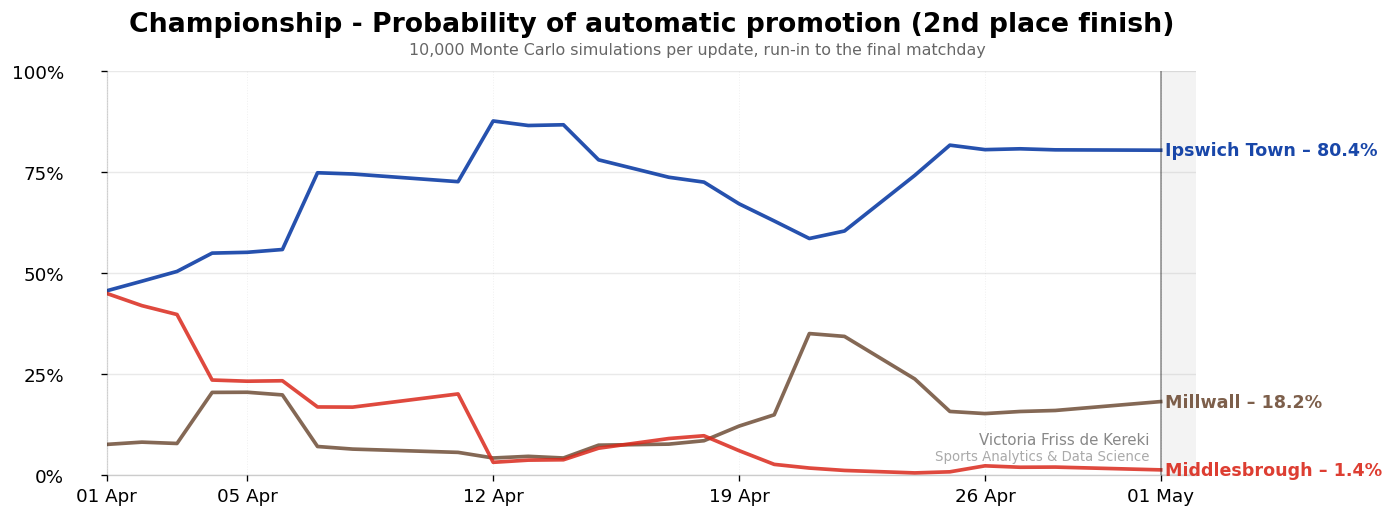

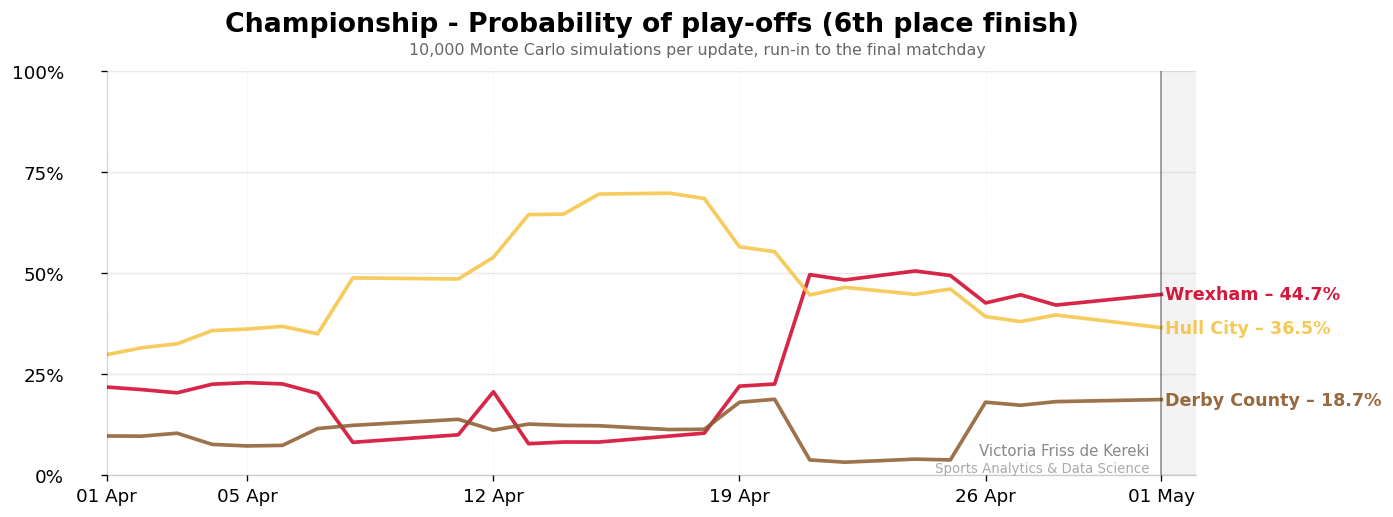

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import pandas as pd
import os

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "figure.dpi": 120
})

TEAM_COLOURS = {
    "Ipswich Town": "#0033A0",
    "Millwall": "#6F4E37",
    "Middlesbrough": "#DA291C",
    "Wrexham": "#D00027",
    "Hull City": "#F6C343",
    "Derby County": "#8B5A2B"
}


# -----------------------
# ENSURE OUTPUT DIRECTORY
# -----------------------
OUTPUT_DIR = "Images and others"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def prepare(df):
    df = df.copy()
    df.columns = pd.to_datetime(df.columns).normalize()
    df = df.sort_index(axis=1)

    if df.max().max() <= 1.5:
        df = df * 100

    return df


def build_tick_list(start_ts, end_ts):
    sundays = pd.date_range(start=start_ts, end=end_ts, freq="W-SUN")
    return sorted(set([start_ts] + list(sundays) + [end_ts]))


def plot_race(df, title, subtitle,
              start_date="2026-04-01",
              end_date="2026-05-01"):

    df = prepare(df)

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    df = df.loc[:, (df.columns >= start_ts) & (df.columns <= end_ts)]

    fig, ax = plt.subplots(figsize=(11.5, 4.2), constrained_layout=True)

    ax.set_axisbelow(True)

    # -----------------------
    # FUTURE WINDOW
    # -----------------------
    ax.axvspan(
        end_ts,
        end_ts + pd.Timedelta(days=7),
        color="#b0b0b0",
        alpha=0.15,
        zorder=0
    )

    # -----------------------
    # LINES
    # -----------------------
    for team in df.index:
        ax.plot(
            df.columns,
            df.loc[team],
            linewidth=2.2,
            color=TEAM_COLOURS[team],
            alpha=0.85
        )

    # -----------------------
    # SNAPSHOT LINE
    # -----------------------
    ax.axvline(end_ts, color="#222222", linewidth=0.9, alpha=0.5)

    # -----------------------
    # END LABELS
    # -----------------------
    last_date = df.columns[-1]
    final_values = df[last_date].sort_values(ascending=False)

    label_offset = pd.Timedelta(days=0.12)

    for team, val in final_values.items():
        ax.text(
            last_date + label_offset,
            val,
            f"{team} – {val:.1f}%",
            va="center",
            ha="left",
            fontsize=10.5,
            fontweight="bold",
            color=TEAM_COLOURS[team],
            alpha=0.9
        )

    # -----------------------
    # TITLE
    # -----------------------
    ax.set_title(title, pad=24)

    # -----------------------
    # SUBTITLE
    # -----------------------
    fig.text(
        0.5, 0.905,
        subtitle,
        ha="center",
        fontsize=9.5,
        color="#666666"
    )

    # -----------------------
    # AXES
    # -----------------------
    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_xlim(start_ts, end_ts + pd.Timedelta(days=1))

    tick_positions = build_tick_list(start_ts, end_ts)
    ax.set_xticks(tick_positions)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    ax.tick_params(axis="y", pad=22)

    # -----------------------
    # GRID
    # -----------------------
    ax.grid(True, axis="y", linestyle="-", linewidth=0.85, alpha=0.28)
    ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.18)

    # -----------------------
    # STYLE
    # -----------------------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.15)
    ax.spines["bottom"].set_alpha(0.2)

    return fig, ax


# =========================================================
# RUN
# =========================================================

fig1, ax1 = plot_race(
    second_place,
    "Championship - Probability of automatic promotion (2nd place finish)",
    "10,000 Monte Carlo simulations per update, run-in to the final matchday"
)

fig2, ax2 = plot_race(
    sixth_place,
    "Championship - Probability of play-offs (6th place finish)",
    "10,000 Monte Carlo simulations per update, run-in to the final matchday"
)

# =========================================================
# FOOTERS
# =========================================================

fig1.text(
    0.828, 0.13,
    "Victoria Friss de Kereki",
    ha="right",
    fontsize=9,
    color="#888888"
)

fig1.text(
    0.828, 0.1,
    "Sports Analytics & Data Science",
    ha="right",
    fontsize=8,
    color="#aaaaaa"
)

fig2.text(
    0.828, 0.11,
    "Victoria Friss de Kereki",
    ha="right",
    fontsize=9,
    color="#888888"
)

fig2.text(
    0.828, 0.075,
    "Sports Analytics & Data Science",
    ha="right",
    fontsize=8,
    color="#aaaaaa"
)

# =========================================================
# EXPORT (PUBLICATION STRUCTURE)
# =========================================================

fig1.savefig(f"{OUTPUT_DIR}/championship_promotion_published.png",
             dpi=300, bbox_inches="tight")

fig2.savefig(f"{OUTPUT_DIR}/championship_playoff_published.png",
             dpi=300, bbox_inches="tight")

plt.show()